In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from project_bootstrap import setup_project

sns.set_theme(style="whitegrid")

# 01 — Exploratory Data Analysis

This task is about deciding whether two questions have the same meaning, even if they are phrased differently. In practice, this kind of analysis can be useful for finding duplicate user requests, repeated support questions, or similar records in large text collections.

In this notebook, we keep the analysis simple and descriptive. We will look at the dataset structure, missing values, target balance, a few basic text properties, and several raw examples.


In [2]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_CANDIDATE = NOTEBOOK_DIR if (NOTEBOOK_DIR / "project_bootstrap.py").exists() else NOTEBOOK_DIR.parent

if str(PROJECT_CANDIDATE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CANDIDATE))

PROJECT_ROOT = setup_project()
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_CANDIDATES = [
    DATA_DIR / "quora_question_pairs_train.csv",
    DATA_DIR / "quora_question_pairs_train.csv.zip",
]

train_path = next((p for p in TRAIN_CANDIDATES if p.exists()), None)
if train_path is None:
    raise FileNotFoundError(
        "Training file was not found. Expected one of: "
        + ", ".join(p.name for p in TRAIN_CANDIDATES)
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Training file: {train_path.name}")

Project root: D:\Git\Quora-project
Training file: quora_question_pairs_train.csv.zip


In [3]:
df = pd.read_csv(train_path)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1


## 1. First look

We start with the basics:
- how many rows and columns the dataset has;
- what each column contains;
- whether the target column is present.


In [4]:
print(f"Shape: {df.shape}")
print()
print("Columns:")
print(df.columns.tolist())
print()
df.info()

Shape: (323432, 6)

Columns:
['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 323432 entries, 0 to 323431
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            323432 non-null  int64 
 1   qid1          323432 non-null  int64 
 2   qid2          323432 non-null  int64 
 3   question1     323431 non-null  object
 4   question2     323430 non-null  object
 5   is_duplicate  323432 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 14.8+ MB


At this point, a quick structural check is enough. The goal is simply to understand what the dataset looks like before looking at any patterns inside it.

**Quick note.** The dataset contains **323,432 pairs** and only **6 columns**, so it is structurally simple: two question IDs, two question texts, one row ID, and the binary target. The schema is clean and easy to work with, and the memory footprint is still moderate for local analysis.

## 2. Missing values

Before going further, it is useful to see whether any question text or labels are missing.


In [5]:
missing = (
    df.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
)
missing["missing_share"] = missing["missing_count"] / len(df)
missing.sort_values("missing_count", ascending=False)

,missing_count,missing_share
question2,2,0.000006
question1,1,0.000003
id,0,0.000000
qid1,0,0.000000
qid2,0,0.000000
is_duplicate,0,0.000000


**Quick note.** Missing values are almost absent here: only **1** missing value in `question1` and **2** in `question2`. This is too small to be a real data quality problem, so simple handling such as filling empty strings or dropping those rows would be enough.

## 3. Target distribution

The target column is `is_duplicate`, so one of the first useful checks is the balance between duplicate and non-duplicate pairs.


,count,share
is_duplicate,,
0,204022,0.630803
1,119410,0.369197


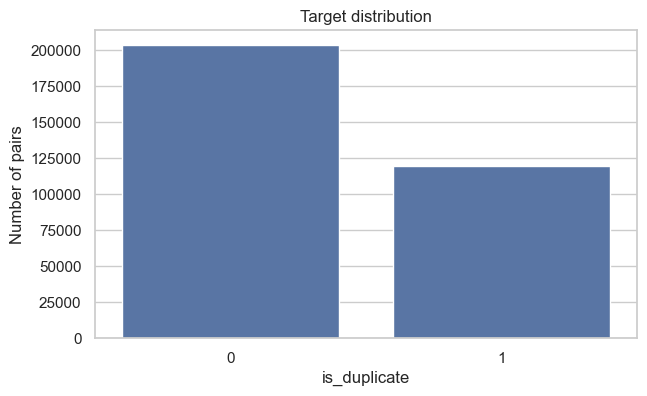

In [6]:
target_counts = df["is_duplicate"].value_counts().sort_index()
target_share = (target_counts / len(df)).rename("share")

display(pd.concat([target_counts.rename("count"), target_share], axis=1))

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="is_duplicate")
ax.set_title("Target distribution")
ax.set_xlabel("is_duplicate")
ax.set_ylabel("Number of pairs")
plt.show()

**Quick note.** The classes are **not perfectly balanced**, but the imbalance is still moderate: about **63.1%** non-duplicates versus **36.9%** duplicates. This means the task is not trivial, but the target is not so skewed that one class completely dominates the dataset.

## 4. Question reuse

Another useful dataset-level check is whether the same questions appear in many different pairs.  
This helps us understand whether the data contains repeated questions or mostly one-off examples.


In [7]:
all_qids = pd.concat([df["qid1"], df["qid2"]], ignore_index=True)
qid_freq = all_qids.value_counts()

summary_qids = pd.Series({
    "unique_question_ids": int(qid_freq.shape[0]),
    "question_ids_seen_once": int((qid_freq == 1).sum()),
    "question_ids_seen_more_than_once": int((qid_freq > 1).sum()),
})

summary_qids.to_frame(name="value")

,value
unique_question_ids,449792
question_ids_seen_once,363895
question_ids_seen_more_than_once,85897


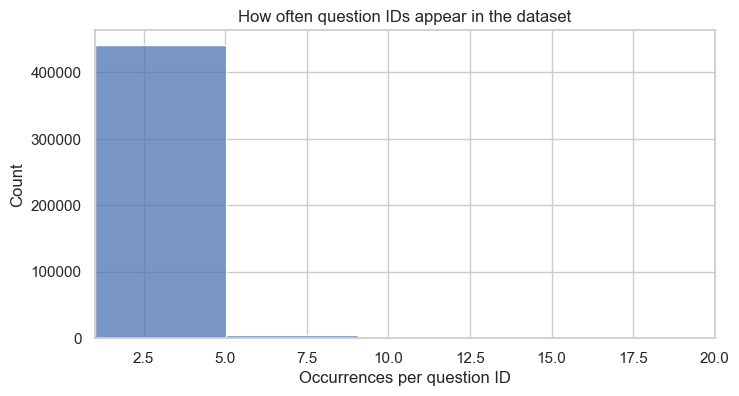

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(qid_freq, bins=30)
plt.title("How often question IDs appear in the dataset")
plt.xlabel("Occurrences per question ID")
plt.ylabel("Count")
plt.xlim(1, min(20, int(qid_freq.max())))
plt.show()

**Quick note.** There are **449,792 unique question IDs** in total, and **85,897** of them appear more than once. So the dataset is not made only of unique one-off questions: some questions are reused across different pairs, which is realistic for a duplicate-detection task.

## 5. Basic text length

Here we stay with very simple descriptive properties of the raw text:
- question length in characters;
- question length in words.


In [9]:
eda = df.copy()
eda["question1"] = eda["question1"].fillna("")
eda["question2"] = eda["question2"].fillna("")

eda["q1_n_chars"] = eda["question1"].str.len()
eda["q2_n_chars"] = eda["question2"].str.len()
eda["q1_n_words"] = eda["question1"].str.split().str.len()
eda["q2_n_words"] = eda["question2"].str.split().str.len()

eda[["q1_n_chars", "q2_n_chars", "q1_n_words", "q2_n_words"]].describe().T

,count,mean,std,min,25%,50%,75%,max
q1_n_chars,323432.0,59.531401,29.921415,0.0,39.0,52.0,72.0,623.0
q2_n_chars,323432.0,60.123065,33.889948,0.0,39.0,51.0,72.0,1169.0
q1_n_words,323432.0,10.941654,5.426303,0.0,7.0,10.0,13.0,125.0
q2_n_words,323432.0,11.184515,6.312230,0.0,7.0,10.0,13.0,237.0


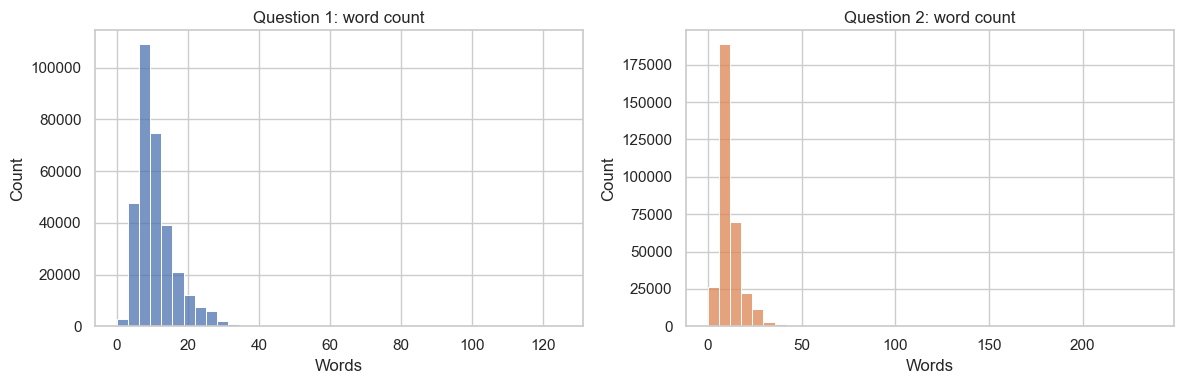

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda["q1_n_words"], bins=40, ax=axes[0], color="C0")
axes[0].set_title("Question 1: word count")
axes[0].set_xlabel("Words")

sns.histplot(eda["q2_n_words"], bins=40, ax=axes[1], color="C1")
axes[1].set_title("Question 2: word count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

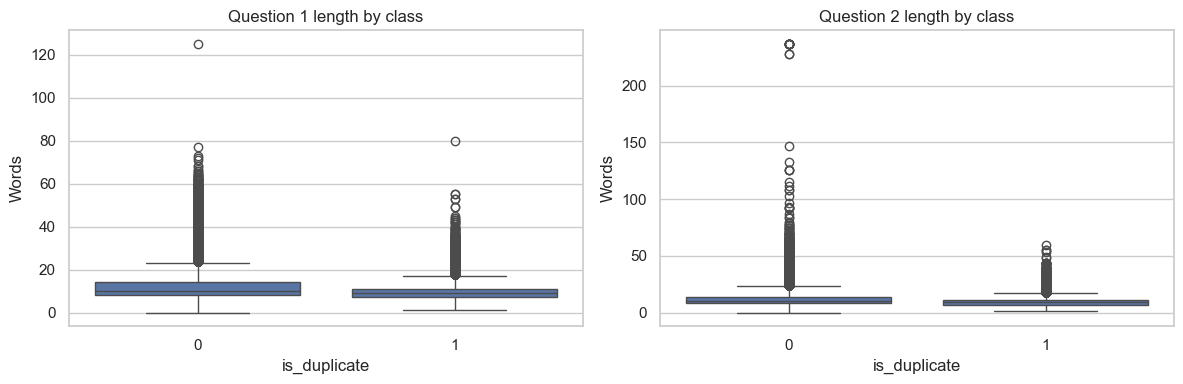

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=eda, x="is_duplicate", y="q1_n_words", ax=axes[0])
axes[0].set_title("Question 1 length by class")
axes[0].set_xlabel("is_duplicate")
axes[0].set_ylabel("Words")

sns.boxplot(data=eda, x="is_duplicate", y="q2_n_words", ax=axes[1])
axes[1].set_title("Question 2 length by class")
axes[1].set_xlabel("is_duplicate")
axes[1].set_ylabel("Words")

plt.tight_layout()
plt.show()

**Quick note.** Most questions are fairly short. The median is about **10 words** and roughly **51–52 characters** for both columns. At the same time, the long right tail shows that the dataset also contains some unusually long questions, so length-based features may vary quite a bit from pair to pair.

## 6. A few examples from each class

Looking at a small number of raw examples helps keep the analysis grounded.  
It is often the fastest way to see what “duplicate” and “non-duplicate” mean in practice.


In [12]:
dup_examples = (
    df.loc[df["is_duplicate"] == 1, ["question1", "question2"]]
      .sample(5, random_state=42)
      .reset_index(drop=True)
)
dup_examples

,question1,question2
0,What about the IAS coaching at Mukherjee Nagar?,What are the best IAS coaching centres in Mukh...
1,Why did Sanskrit fail to become a suitable lan...,It has been claimed several times that Sanskri...
2,How will demonitization stop black money?,Will demonetisation really curb black money?
3,How can i get rid of lower back pain?,How do I reduce lower back pain?
4,Did nasa really go to the moon?,Did man really land on the moon?


In [13]:
nondup_examples = (
    df.loc[df["is_duplicate"] == 0, ["question1", "question2"]]
      .sample(5, random_state=42)
      .reset_index(drop=True)
)
nondup_examples

,question1,question2
0,What is it like to interview a genius?,What are some smart answers given to an interv...
1,How do top students study?,How do I become a top student?
2,What are the best courses to be done for job i...,What are good courses related to software test...
3,Could we detect a Dyson Sphere?,What's a Dyson sphere?
4,Who are the main characters in Mahabharata?,What are the main characters of the Mahabharat...


**Quick note.** The sampled duplicate pairs usually express the **same intent with different wording**, while the non-duplicate examples are more mixed: some are clearly different, while others look superficially similar but ask for something more specific or slightly different. This confirms that the task is not only about shared words, but also about meaning.

## 7. EDA summary

From this first pass, the dataset looks clean and easy to work with. It contains **323k question pairs**, has almost no missing values, and uses a binary target with a moderate class imbalance in favor of non-duplicates.

The questions themselves are usually short, but their lengths still vary enough to make simple descriptive features potentially useful. Another important point is that many question IDs appear in more than one pair, which suggests that repeated questions are a real pattern in the data rather than a rare exception.

Overall, the dataset already looks suitable for duplicate-question detection: it is large enough, mostly clean, and varied enough to make the classification task meaningful.